# BDD100K Object Detection — Full Pipeline
### Google Colab + Free T4 GPU

| # | Step |
|---|------|
| 1 | Check GPU |
| 2 | Install packages |
| 3 | Upload kaggle.json → download dataset |
| 4 | Detect paths |
| 5 | Write project code |
| 6 | Data Analysis |
| 7 | Model Training |
| 8 | Inference |
| 9 | Evaluation (mAP) |
| 10 | Failure Clustering |
| 11 | Save to Google Drive |

---
⚠️ **First:** `Runtime → Change runtime type → T4 GPU → Save`

## CELL 1 — Check GPU

In [1]:
import torch
print('PyTorch  :', torch.__version__)
print('GPU      :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name :', torch.cuda.get_device_name(0))
    print('GPU mem  :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')

PyTorch  : 2.10.0+cu128
GPU      : True
GPU name : Tesla T4
GPU mem  : 15.6 GB


## CELL 2 — Install Packages

In [2]:
!pip install -q torchmetrics seaborn scikit-learn kaggle
print('✅ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.8 MB/s eta 0:00:00
✅ All packages installed


## CELL 3 — Upload Dataset via Google Drive

**One-time setup (~1 minute):**
1. Go to [drive.google.com](https://drive.google.com) and upload `mini_bdd100k.zip`
2. Wait for the upload to finish
3. Run the cells below — they will mount your Drive and extract the dataset automatically

> ✅ The mini zip is only ~30 MB — 100 train + 20 val samples per class (10 classes total).

In [5]:
from google.colab import drive

drive.mount('/content/drive')
print('✅ Google Drive mounted at /content/drive')

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [6]:
import os, glob, zipfile

# Find mini_bdd100k.zip anywhere inside Google Drive
matches = glob.glob('/content/drive/MyDrive/**/mini_bdd100k.zip', recursive=True)
if not matches:
    raise FileNotFoundError(
        '❌ mini_bdd100k.zip not found in Google Drive.\n'
        'Please upload mini_bdd100k.zip to your Drive and re-run.'
    )

ZIP_PATH = matches[0]
print(f'Found: {ZIP_PATH}  ({os.path.getsize(ZIP_PATH)/1e6:.0f} MB)')

EXTRACT_DIR = '/content'
print(f'Extracting to {EXTRACT_DIR} ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print('✅ Extraction complete')

Found: /content/drive/MyDrive/mini_bdd100k.zip  (30 MB)
Extracting to /content ...
✅ Extraction complete


## CELL 4 — Detect Dataset Paths

In [7]:
import os

# zip extracts directly into /content, creating bdd100k/, bdd100k_labels_release/, bdd100k_seg/
DATA_DIR = '/content'

print('=== FOLDER STRUCTURE ===')
for root, dirs, files in os.walk(DATA_DIR):
    # Skip drive mount and colab system folders
    dirs[:] = [d for d in dirs
               if d not in ('drive', 'sample_data', 'project', 'outputs')]
    depth = root.replace(DATA_DIR, '').count(os.sep)
    if depth > 6: continue
    indent = '  ' * depth
    folder = os.path.basename(root) or DATA_DIR
    jpg  = sum(1 for f in files if f.endswith('.jpg'))
    json = sum(1 for f in files if f.endswith('.json'))
    tag  = f'  ← {jpg} images' if jpg else (f'  ← {json} JSON files' if json else '')
    print(f'{indent}{folder}/  ({len(files)} files){tag}')

=== FOLDER STRUCTURE ===
content/  (0 files)
  .config/  (8 files)  ← 1 JSON files
    logs/  (0 files)
      2026.02.06/  (6 files)
    configurations/  (1 files)
  bdd100k/  (0 files)
    bdd100k/  (0 files)
      images/  (0 files)
        100k/  (0 files)
          train/  (397 files)  ← 397 images
          val/  (104 files)  ← 104 images
  bdd100k_labels_release/  (0 files)
    bdd100k/  (0 files)
      labels/  (2 files)  ← 2 JSON files


In [8]:
import os

# zip extracts into /content, so top-level folders are:
#   /content/bdd100k/bdd100k/images/100k/train|val
#   /content/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train|val.json
DATA_DIR = '/content'

TRAIN_LABELS = None
VAL_LABELS   = None
TRAIN_IMAGES = None
VAL_IMAGES   = None

for root, dirs, files in os.walk(DATA_DIR):
    # Skip drive and colab system dirs to keep the walk fast
    dirs[:] = [d for d in dirs
               if d not in ('drive', 'sample_data', 'project', 'outputs')]

    folder = os.path.basename(root)
    parent = os.path.basename(os.path.dirname(root))

    # Labels: JSON inside a 'labels' folder, not under seg
    if folder == 'labels' and 'seg' not in root:
        for f in files:
            full = os.path.join(root, f)
            if f.endswith('.json') and 'train' in f.lower():
                TRAIN_LABELS = full
            if f.endswith('.json') and 'val' in f.lower():
                VAL_LABELS = full

    # Images: specifically 100k/train and 100k/val (not seg images)
    has_jpg = any(f.endswith('.jpg') for f in files)
    if folder == 'train' and parent == '100k' and has_jpg:
        TRAIN_IMAGES = root
    if folder == 'val' and parent == '100k' and has_jpg:
        VAL_IMAGES = root

print('Paths found:')
print(f'  TRAIN_LABELS : {TRAIN_LABELS}')
print(f'  VAL_LABELS   : {VAL_LABELS}')
print(f'  TRAIN_IMAGES : {TRAIN_IMAGES}')
print(f'  VAL_IMAGES   : {VAL_IMAGES}')

if TRAIN_IMAGES: print(f'\n  Train images : {len(os.listdir(TRAIN_IMAGES)):,}')
if VAL_IMAGES:   print(f'  Val images   : {len(os.listdir(VAL_IMAGES)):,}')

assert all([TRAIN_LABELS, VAL_LABELS, TRAIN_IMAGES, VAL_IMAGES]), \
    'Some paths not found! Check the folder tree output above.'
print('\n✅ All paths verified — ready to proceed')

Paths found:
  TRAIN_LABELS : /content/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json
  VAL_LABELS   : /content/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json
  TRAIN_IMAGES : /content/bdd100k/bdd100k/images/100k/train
  VAL_IMAGES   : /content/bdd100k/bdd100k/images/100k/val

  Train images : 397
  Val images   : 104

✅ All paths verified — ready to proceed


## CELL 5 — Write Project Code

In [9]:
import os
for d in ['/content/project/parser', '/content/project/model',
          '/content/outputs/precomputed/figures', '/content/outputs/model',
          '/content/outputs/eval', '/content/outputs/qual',
          '/content/outputs/failures']:
    os.makedirs(d, exist_ok=True)
print('✅ Directories created')

✅ Directories created


In [10]:
%%writefile /content/project/parser/bdd_parser.py
"""
BDD100K label parser — reads JSON labels into Python objects.
"""
import json, os
from dataclasses import dataclass, field
from typing import List, Optional, Dict
from PIL import Image

BDD_DETECTION_CLASSES = [
    'car','traffic sign','traffic light','person',
    'truck','bus','bike','rider','motor','train',
]

@dataclass
class BoundingBox:
    x1: float; y1: float; x2: float; y2: float
    @property
    def width(self):        return self.x2 - self.x1
    @property
    def height(self):       return self.y2 - self.y1
    @property
    def area(self):         return self.width * self.height
    @property
    def aspect_ratio(self): return self.width / self.height if self.height > 0 else 0
    def is_valid(self):     return self.width > 0 and self.height > 0

@dataclass
class Annotation:
    category: str
    bbox: BoundingBox
    occluded: bool = False
    truncated: bool = False
    attributes: Dict = field(default_factory=dict)

@dataclass
class Sample:
    image_name: str
    annotations: List[Annotation]
    image_path: Optional[str] = None
    weather: Optional[str] = None
    scene: Optional[str] = None
    time_of_day: Optional[str] = None
    def load_image(self):
        if self.image_path and os.path.exists(self.image_path):
            return Image.open(self.image_path).convert('RGB')
        return None
    @property
    def num_annotations(self): return len(self.annotations)
    @property
    def classes_present(self): return list({a.category for a in self.annotations})
    def is_empty(self):        return len(self.annotations) == 0

class BDDParser:
    """Parses BDD100K label JSON into Sample objects."""
    def __init__(self, label_path: str, image_dir: str):
        self.label_path = label_path
        self.image_dir  = image_dir
        self.samples: List[Sample] = []

    def parse(self) -> List[Sample]:
        with open(self.label_path) as f:
            data = json.load(f)
        self.samples = []
        for entry in data:
            attrs = entry.get('attributes', {})
            self.samples.append(Sample(
                image_name=entry['name'],
                annotations=self._parse_labels(entry.get('labels', [])),
                image_path=os.path.join(self.image_dir, entry['name']),
                weather=attrs.get('weather'),
                scene=attrs.get('scene'),
                time_of_day=attrs.get('timeofday'),
            ))
        return self.samples

    def _parse_labels(self, labels):
        result = []
        for lbl in labels:
            cat = lbl.get('category', '')
            if cat not in BDD_DETECTION_CLASSES: continue
            b = lbl.get('box2d')
            if b is None: continue
            bbox = BoundingBox(b['x1'], b['y1'], b['x2'], b['y2'])
            if not bbox.is_valid(): continue
            a = lbl.get('attributes', {})
            result.append(Annotation(cat, bbox,
                bool(a.get('occluded', False)),
                bool(a.get('truncated', False)), a))
        return result

Writing /content/project/parser/bdd_parser.py


In [11]:
%%writefile /content/project/model/bdd_dataset.py
"""
PyTorch Dataset for BDD100K — compatible with Faster R-CNN.
"""
import json, os
from typing import Callable, List, Optional
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms as T

BDD_CLASSES  = ['car','traffic sign','traffic light','person',
                 'truck','bus','bike','rider','motor','train']
CLASS_TO_IDX = {c: i+1 for i, c in enumerate(BDD_CLASSES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
IDX_TO_CLASS[0] = 'background'

def collate_fn(batch):
    return tuple(zip(*batch))

class BDD100KDataset(Dataset):
    """BDD100K detection dataset for Faster R-CNN."""
    def __init__(self, image_dir, label_path,
                 transforms=None, max_samples=None):
        self.image_dir  = image_dir
        self.transforms = transforms
        self._to_tensor = T.ToTensor()
        self.samples    = self._load(label_path, image_dir, max_samples)

    def _load(self, label_path, image_dir, max_samples):
        with open(label_path) as f: data = json.load(f)
        samples = []
        for entry in data:
            if not os.path.exists(os.path.join(image_dir, entry['name'])): continue
            boxes, labels = [], []
            for lbl in entry.get('labels', []):
                cat = lbl.get('category', '')
                if cat not in CLASS_TO_IDX or not lbl.get('box2d'): continue
                b = lbl['box2d']
                if b['x2'] <= b['x1'] or b['y2'] <= b['y1']: continue
                boxes.append([b['x1'], b['y1'], b['x2'], b['y2']])
                labels.append(CLASS_TO_IDX[cat])
            if boxes:
                samples.append({'image_name': entry['name'],
                                'boxes': boxes, 'labels': labels})
        if max_samples: samples = samples[:max_samples]
        print(f'  [Dataset] {len(samples)} samples loaded')
        return samples

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(os.path.join(self.image_dir, s['image_name'])).convert('RGB')
        boxes  = torch.tensor(s['boxes'],  dtype=torch.float32)
        labels = torch.tensor(s['labels'], dtype=torch.int64)
        target = {
            'boxes'   : boxes,
            'labels'  : labels,
            'image_id': torch.tensor([idx]),
            'area'    : (boxes[:,3]-boxes[:,1])*(boxes[:,2]-boxes[:,0]),
            'iscrowd' : torch.zeros(len(labels), dtype=torch.uint8),
        }
        img = self.transforms(img) if self.transforms else self._to_tensor(img)
        return img, target

Writing /content/project/model/bdd_dataset.py


## CELL 6 — DATA ANALYSIS
Parse labels → class distribution → bbox stats → anomalies → visualize sample

In [12]:
import sys
sys.path.insert(0, '/content/project')

from parser.bdd_parser import BDDParser, BDD_DETECTION_CLASSES
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
import numpy as np
import os

print('Parsing train labels...')
train_parser  = BDDParser(TRAIN_LABELS, TRAIN_IMAGES)
train_samples = train_parser.parse()
print(f'  {len(train_samples):,} train samples')

print('Parsing val labels...')
val_parser  = BDDParser(VAL_LABELS, VAL_IMAGES)
val_samples = val_parser.parse()
print(f'  {len(val_samples):,} val samples')

all_samples = train_samples + val_samples
print(f'Total: {len(all_samples):,} samples')

Parsing train labels...
  397 train samples
Parsing val labels...
  104 val samples
Total: 501 samples


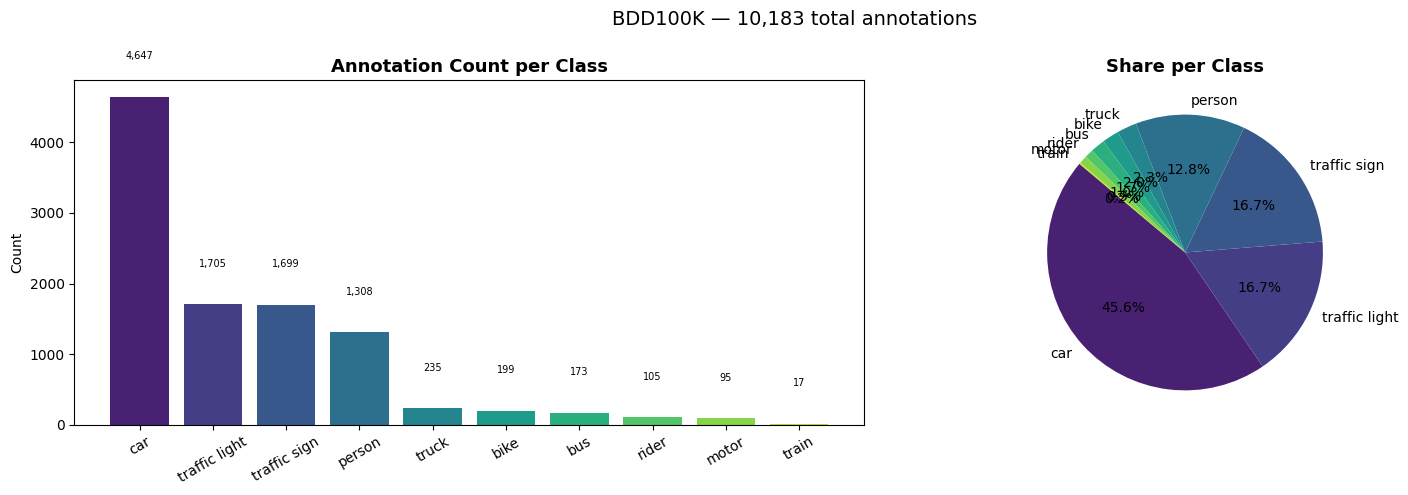

        class  count
          car   4647
traffic light   1705
 traffic sign   1699
       person   1308
        truck    235
         bike    199
          bus    173
        rider    105
        motor     95
        train     17

⚠️  car is 273x more common than train


In [13]:
# 6a — Class Distribution
counter = Counter(ann.category for s in all_samples for ann in s.annotations)
df_dist = pd.DataFrame(
    [{'class': c, 'count': counter.get(c, 0)} for c in BDD_DETECTION_CLASSES]
).sort_values('count', ascending=False)

colors = sns.color_palette('viridis', len(df_dist))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(df_dist['class'], df_dist['count'], color=colors)
axes[0].set_title('Annotation Count per Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, df_dist['count']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+500,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=7)

axes[1].pie(df_dist['count'], labels=df_dist['class'],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Share per Class', fontsize=13, fontweight='bold')

plt.suptitle(f'BDD100K — {df_dist["count"].sum():,} total annotations', fontsize=14)
plt.tight_layout()
plt.savefig('/content/outputs/precomputed/figures/class_distribution.png', dpi=150)
plt.show()

print(df_dist.to_string(index=False))
mx = df_dist.iloc[0]; mn = df_dist.iloc[-1]
print(f'\n⚠️  {mx["class"]} is {int(mx["count"]/max(mn["count"],1)):,}x more common than {mn["class"]}')

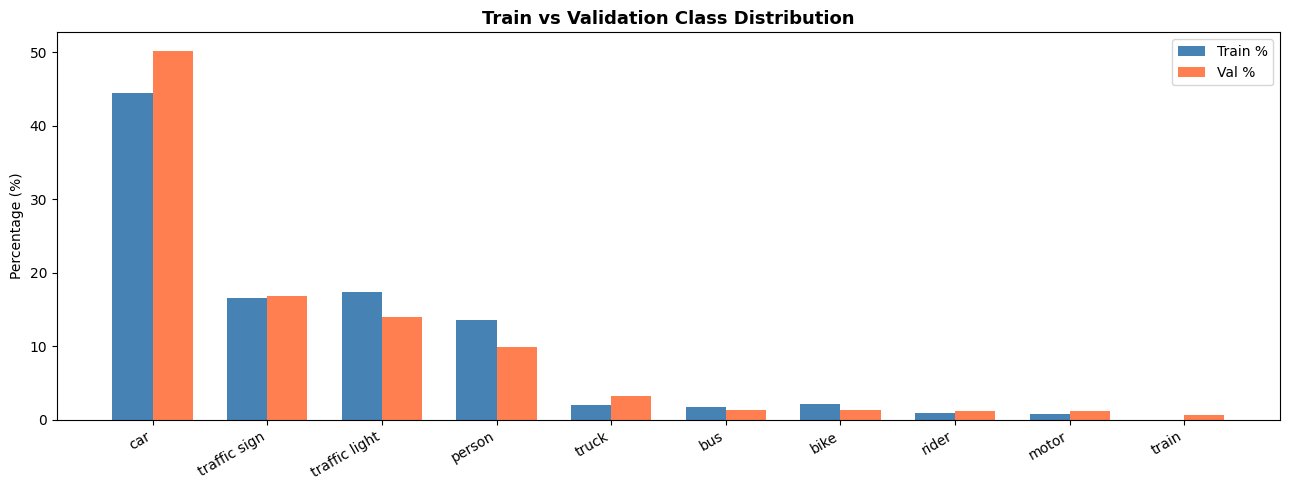

✅ Train & Val are well balanced


In [14]:
# 6b — Train vs Val Comparison
tc = Counter(ann.category for s in train_samples for ann in s.annotations)
vc = Counter(ann.category for s in val_samples   for ann in s.annotations)

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(BDD_DETECTION_CLASSES)); w = 0.35
tp = [tc.get(c,0)/sum(tc.values())*100 for c in BDD_DETECTION_CLASSES]
vp = [vc.get(c,0)/sum(vc.values())*100 for c in BDD_DETECTION_CLASSES]
ax.bar([i-w/2 for i in x], tp, w, label='Train %', color='steelblue')
ax.bar([i+w/2 for i in x], vp, w, label='Val %',   color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(BDD_DETECTION_CLASSES, rotation=30, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Train vs Validation Class Distribution', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/outputs/precomputed/figures/train_val_comparison.png', dpi=150)
plt.show()
print('✅ Train & Val are well balanced')

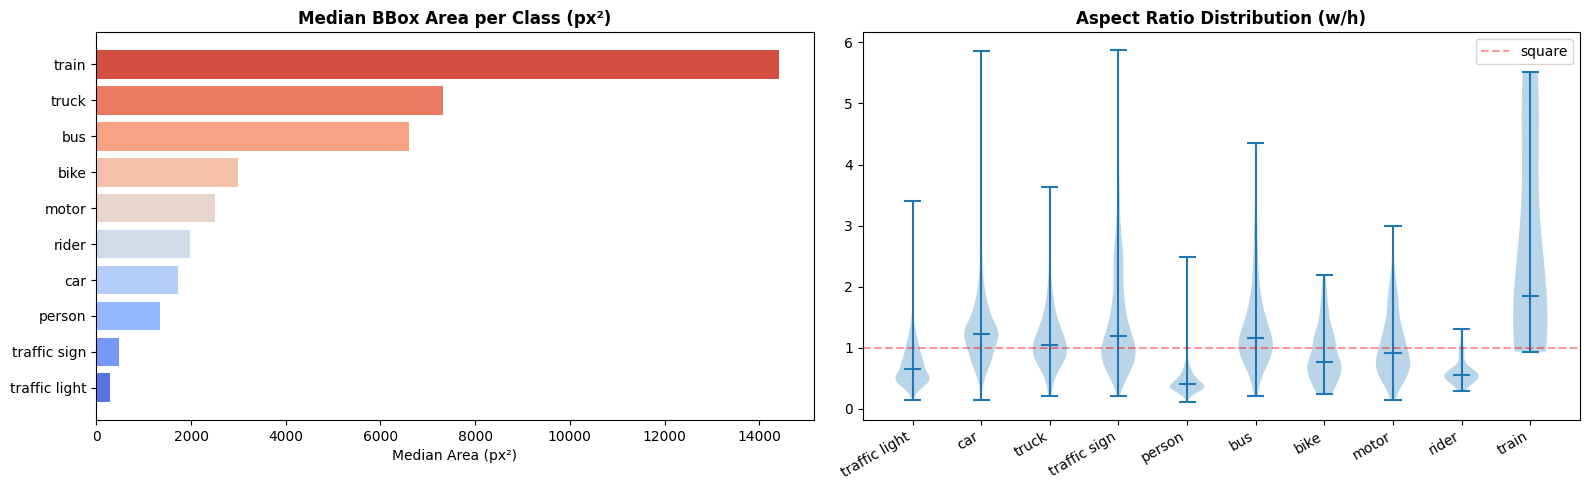

In [15]:
# 6c — BBox Size & Aspect Ratio
bbox_data = [{'class': ann.category,
              'area': ann.bbox.area,
              'ar': ann.bbox.aspect_ratio}
             for s in all_samples for ann in s.annotations]
df_bbox = pd.DataFrame(bbox_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stats = df_bbox.groupby('class')['area'].median().sort_values()
axes[0].barh(stats.index, stats.values,
             color=sns.color_palette('coolwarm', len(stats)))
axes[0].set_title('Median BBox Area per Class (px²)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median Area (px²)')

ar_clip  = df_bbox[df_bbox['ar'].between(0.1, 6)]
classes  = list(ar_clip['class'].unique())
data_cls = [ar_clip[ar_clip['class']==c]['ar'].values for c in classes]
axes[1].violinplot(data_cls, showmedians=True)
axes[1].set_xticks(range(1, len(classes)+1))
axes[1].set_xticklabels(classes, rotation=30, ha='right')
axes[1].set_title('Aspect Ratio Distribution (w/h)', fontsize=12, fontweight='bold')
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.4, label='square')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/outputs/precomputed/figures/bbox_analysis.png', dpi=150)
plt.show()

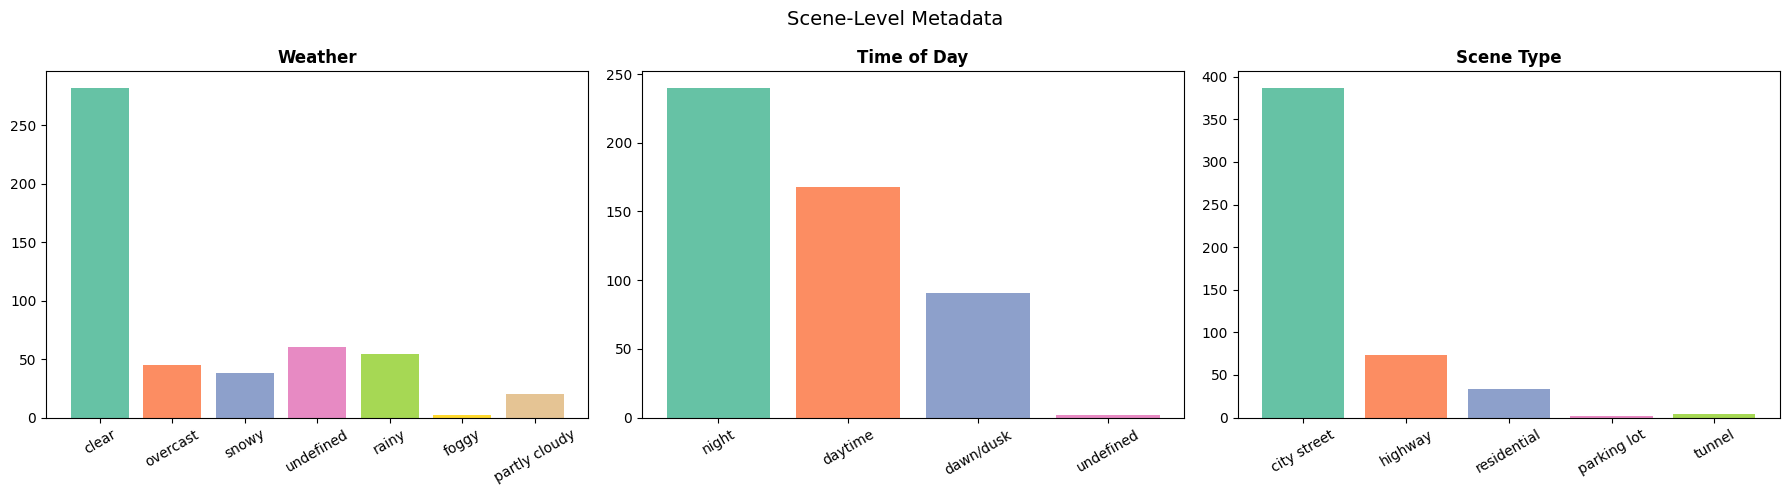

Weather: {'clear': 282, 'overcast': 45, 'snowy': 38, 'undefined': 60, 'rainy': 54, 'foggy': 2, 'partly cloudy': 20}
Time   : {'night': 240, 'daytime': 168, 'dawn/dusk': 91, 'undefined': 2}


In [16]:
# 6d — Scene Metadata
wc = Counter(s.weather     for s in all_samples if s.weather)
tc = Counter(s.time_of_day for s in all_samples if s.time_of_day)
sc = Counter(s.scene       for s in all_samples if s.scene)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, title, counts in zip(axes,
        ['Weather', 'Time of Day', 'Scene Type'], [wc, tc, sc]):
    ax.bar(counts.keys(), counts.values(),
           color=sns.color_palette('Set2', len(counts)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Scene-Level Metadata', fontsize=14)
plt.tight_layout()
plt.savefig('/content/outputs/precomputed/figures/scene_metadata.png', dpi=150)
plt.show()
print('Weather:', dict(wc))
print('Time   :', dict(tc))

In [17]:
# 6e — Anomaly Detection
empty   = [s for s in all_samples if s.is_empty()]
crowded = sorted([(s, s.num_annotations) for s in all_samples
                  if s.num_annotations >= 30], key=lambda x: -x[1])
tiny    = [(s, ann) for s in all_samples
           for ann in s.annotations if ann.bbox.area < 50]
occ     = sorted([(s, sum(a.occluded for a in s.annotations)/s.num_annotations)
                  for s in all_samples if s.num_annotations > 0
                  and sum(a.occluded for a in s.annotations)/s.num_annotations >= 0.8],
                 key=lambda x: -x[1])

print('='*52)
print('ANOMALY SUMMARY')
print('='*52)
print(f'  Empty samples (no annotations)   : {len(empty):,}')
print(f'  Crowded samples (≥30 objects)    : {len(crowded):,}')
print(f'  Tiny boxes (area < 50 px²)       : {len(tiny):,}')
print(f'  Heavily occluded (≥80% occluded) : {len(occ):,}')
print()
print('Top 5 most crowded images:')
for s, n in crowded[:5]:
    print(f'  {s.image_name}  {n} objects | {s.time_of_day} | {s.weather}')

ANOMALY SUMMARY
  Empty samples (no annotations)   : 0
  Crowded samples (≥30 objects)    : 74
  Tiny boxes (area < 50 px²)       : 24
  Heavily occluded (≥80% occluded) : 28

Top 5 most crowded images:
  8d091799-5c28a01c.jpg  63 objects | night | clear
  6a36991f-5f380c0d.jpg  61 objects | night | clear
  17d2c5d1-3da97736.jpg  55 objects | night | clear
  58fef603-0ba8e58b.jpg  51 objects | daytime | undefined
  0e48b61d-831f1846.jpg  48 objects | daytime | partly cloudy


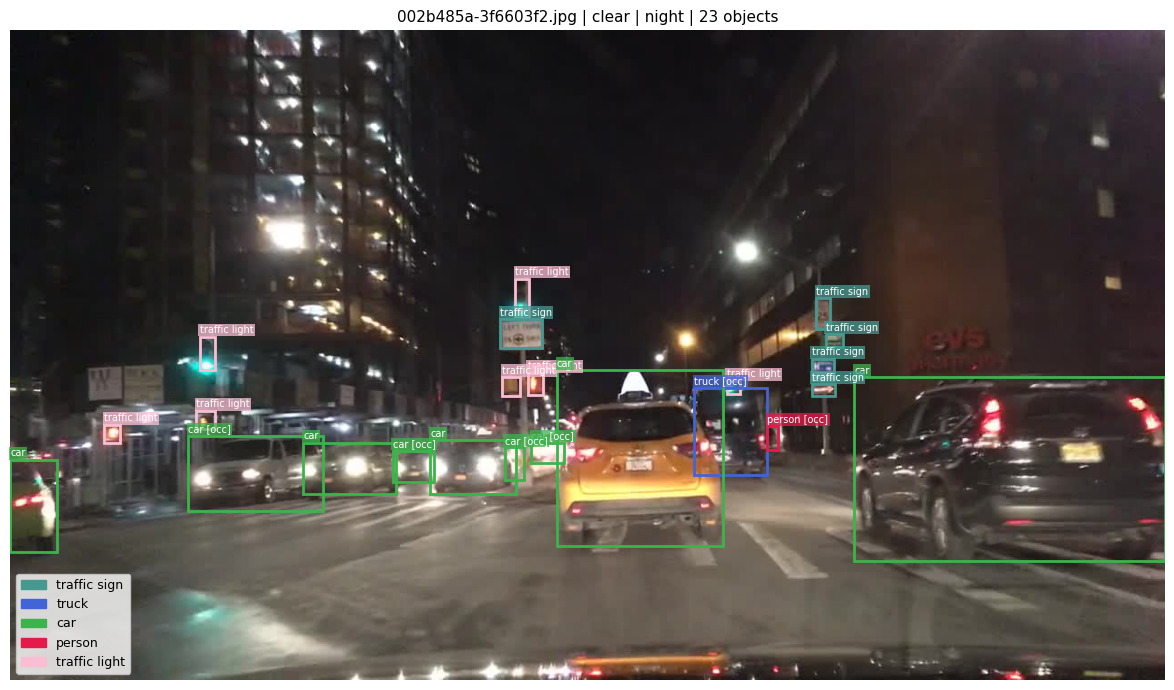

✅ Classes visible: ['traffic sign', 'truck', 'car', 'person', 'traffic light']


In [18]:
# 6f — Visualize a real annotated image
CLASS_COLORS = {
    'car':'#3cb44b', 'traffic sign':'#469990', 'traffic light':'#fabed4',
    'person':'#e6194b', 'truck':'#4363d8', 'bus':'#911eb4',
    'bike':'#bfef45', 'rider':'#f58231', 'motor':'#f032e6', 'train':'#42d4f4'
}

chosen = next((s for s in train_samples
               if s.image_path and os.path.exists(s.image_path)
               and len(s.classes_present) >= 3
               and s.num_annotations >= 5), None)

if chosen:
    img = chosen.load_image()
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.imshow(img); ax.axis('off')
    ax.set_title(
        f'{chosen.image_name} | {chosen.weather} | {chosen.time_of_day} | {chosen.num_annotations} objects',
        fontsize=11)
    for ann in chosen.annotations:
        color = CLASS_COLORS.get(ann.category, 'white')
        ax.add_patch(mpatches.Rectangle(
            (ann.bbox.x1, ann.bbox.y1), ann.bbox.width, ann.bbox.height,
            linewidth=2, edgecolor=color, facecolor='none'))
        ax.text(ann.bbox.x1, max(ann.bbox.y1-4,0),
                ann.category + (' [occ]' if ann.occluded else ''),
                color='white', fontsize=7,
                bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))
    patches = [mpatches.Patch(color=CLASS_COLORS[c], label=c)
               for c in chosen.classes_present]
    ax.legend(handles=patches, loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.savefig('/content/outputs/precomputed/figures/sample_annotated.png', dpi=120)
    plt.show()
    print(f'✅ Classes visible: {chosen.classes_present}')
else:
    print('No matching sample on disk')

## CELL 7 — MODEL TRAINING
**Architecture: Faster R-CNN + ResNet-50 + FPN**
```
Image → ResNet-50 backbone → FPN (multi-scale)
                                    ↓
                         RPN: "is there an object?"
                                    ↓
              Classification Head: "what class? where exactly?"
```
Training on **10 images per class** (~50-60 total) — enough to see the full pipeline flow.

In [19]:
import sys, json, os, torch, time
sys.path.insert(0, '/content/project')

from torch.utils.data import DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from model.bdd_dataset import BDD100KDataset, BDD_CLASSES, IDX_TO_CLASS, collate_fn

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = len(BDD_CLASSES) + 1   # +1 for background
print(f'Device     : {DEVICE}')
print(f'Num classes: {NUM_CLASSES}  (10 BDD + 1 background)')

print('\nBuilding Faster R-CNN with COCO pretrained weights...')
model   = fasterrcnn_resnet50_fpn(pretrained=True)
in_feat = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
model   = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params     : {total/1e6:.1f}M total | {trainable/1e6:.1f}M trainable')
print('✅ Model ready')

Device     : cuda
Num classes: 11  (10 BDD + 1 background)

Building Faster R-CNN with COCO pretrained weights...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 188MB/s]


Params     : 41.3M total | 41.1M trainable
✅ Model ready


In [20]:
# Build mini dataset: 10 images per class
with open(TRAIN_LABELS) as f:
    all_labels = json.load(f)

picked, seen, mini = {}, set(), []
for entry in all_labels:
    img_path = os.path.join(TRAIN_IMAGES, entry['name'])
    if not os.path.exists(img_path): continue
    cats = {l['category'] for l in entry.get('labels', [])
            if l.get('box2d') and l['category'] in BDD_CLASSES}
    for cat in cats:
        picked.setdefault(cat, [])
        if len(picked[cat]) < 10:
            picked[cat].append(entry)
    if entry['name'] not in seen:
        seen.add(entry['name'])
        mini.append(entry)

picked_names = {e['name'] for v in picked.values() for e in v}
mini = [e for e in mini if e['name'] in picked_names]

MINI_PATH = '/content/mini_train.json'
with open(MINI_PATH, 'w') as f:
    json.dump(mini, f)

print(f'Mini dataset: {len(mini)} images')
for cat in BDD_CLASSES:
    print(f'  {cat:<15} {len(picked.get(cat, []))} images')

train_dataset = BDD100KDataset(TRAIN_IMAGES, MINI_PATH)
train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True,
                            num_workers=2, collate_fn=collate_fn)
print(f'\nBatches per epoch: {len(train_loader)}')

Mini dataset: 54 images
  car             10 images
  traffic sign    10 images
  traffic light   10 images
  person          10 images
  truck           10 images
  bus             10 images
  bike            10 images
  rider           10 images
  motor           10 images
  train           2 images
  [Dataset] 54 samples loaded

Batches per epoch: 14


In [21]:
# Training loop
optimizer    = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=5e-4)
EPOCHS       = 3
loss_history = []

for epoch in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for bi, (images, targets) in enumerate(train_loader):
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
        optimizer.step()

        epoch_loss += loss.item()
        bd = {k: f'{v.item():.3f}' for k,v in loss_dict.items()}
        print(f'  Ep{epoch} Batch {bi+1}/{len(train_loader)} | Loss={loss.item():.4f} | {bd}')

    mean = epoch_loss / len(train_loader)
    loss_history.append(mean)
    print(f'\n✅ Epoch {epoch} | Mean loss: {mean:.4f} | Time: {time.time()-t0:.1f}s\n')

ckpt = '/content/outputs/model/model_final.pth'
torch.save({'epoch': EPOCHS, 'model_state_dict': model.state_dict(), 'loss': mean}, ckpt)
print(f'✅ Saved: {ckpt}')

  Ep1 Batch 1/14 | Loss=4.0405 | {'loss_classifier': '2.490', 'loss_box_reg': '0.878', 'loss_objectness': '0.455', 'loss_rpn_box_reg': '0.218'}
  Ep1 Batch 2/14 | Loss=3.0761 | {'loss_classifier': '2.111', 'loss_box_reg': '0.799', 'loss_objectness': '0.074', 'loss_rpn_box_reg': '0.092'}
  Ep1 Batch 3/14 | Loss=2.6587 | {'loss_classifier': '1.424', 'loss_box_reg': '0.832', 'loss_objectness': '0.153', 'loss_rpn_box_reg': '0.249'}
  Ep1 Batch 4/14 | Loss=2.1945 | {'loss_classifier': '1.003', 'loss_box_reg': '0.857', 'loss_objectness': '0.076', 'loss_rpn_box_reg': '0.258'}
  Ep1 Batch 5/14 | Loss=1.9534 | {'loss_classifier': '0.937', 'loss_box_reg': '0.640', 'loss_objectness': '0.212', 'loss_rpn_box_reg': '0.165'}
  Ep1 Batch 6/14 | Loss=2.1599 | {'loss_classifier': '1.095', 'loss_box_reg': '0.787', 'loss_objectness': '0.193', 'loss_rpn_box_reg': '0.085'}
  Ep1 Batch 7/14 | Loss=1.3966 | {'loss_classifier': '0.641', 'loss_box_reg': '0.577', 'loss_objectness': '0.073', 'loss_rpn_box_reg': '

/tmp/ipython-input-295/3248657920.py:10: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-295/3248657920.py:11: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/outputs/model/loss_curve.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


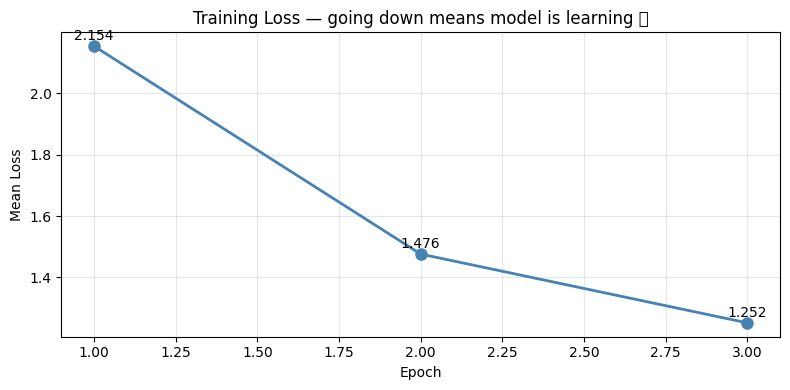

In [22]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history)+1), loss_history,
         'o-', color='steelblue', linewidth=2, markersize=8)
for i, v in enumerate(loss_history):
    plt.text(i+1, v+0.02, f'{v:.3f}', ha='center', fontsize=10)
plt.xlabel('Epoch'); plt.ylabel('Mean Loss')
plt.title('Training Loss — going down means model is learning ✅', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/outputs/model/loss_curve.png', dpi=150)
plt.show()

## CELL 8 — INFERENCE
Run the trained model on 3 random validation images

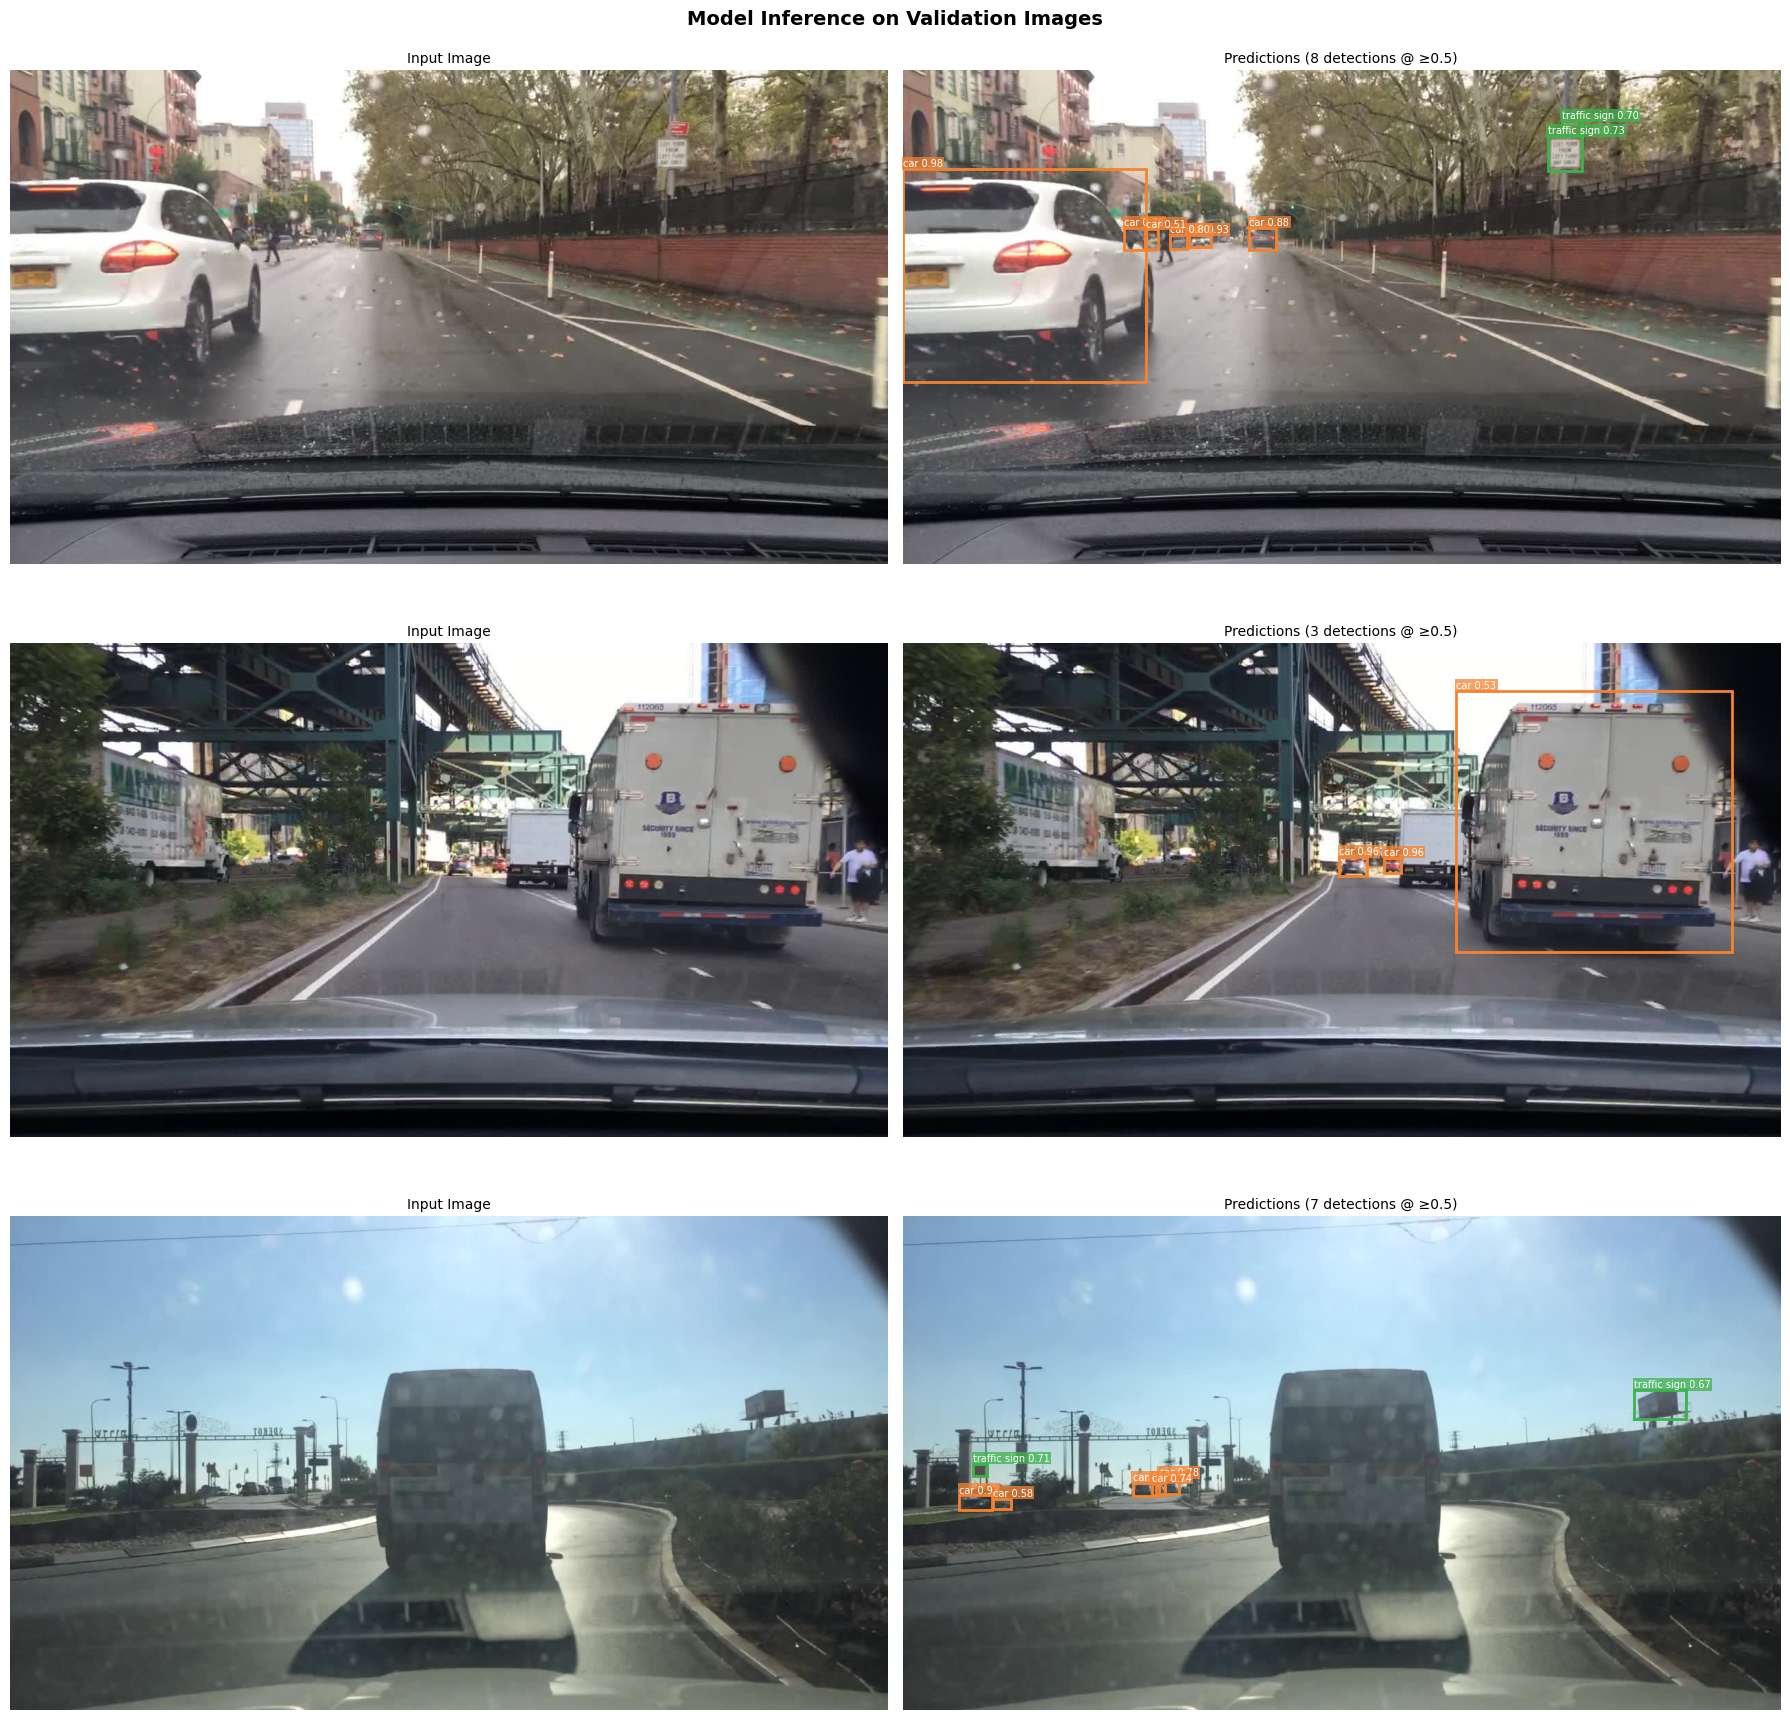

✅ Inference complete


In [23]:
import random
from torchvision import transforms as T
from PIL import Image

COLORS = ['#e6194b','#f58231','#3cb44b','#4363d8','#911eb4',
          '#42d4f4','#f032e6','#bfef45','#fabed4','#469990','#fff']

model.eval()
to_tensor = T.ToTensor()
val_imgs  = random.sample(
    [f for f in os.listdir(VAL_IMAGES) if f.endswith('.jpg')], 3)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for row, fname in enumerate(val_imgs):
    image  = Image.open(os.path.join(VAL_IMAGES, fname)).convert('RGB')
    tensor = to_tensor(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(tensor)[0]

    mask   = out['scores'] >= 0.5
    boxes  = out['boxes'][mask].cpu()
    labels = out['labels'][mask].cpu()
    scores = out['scores'][mask].cpu()

    for ax in axes[row]: ax.imshow(image); ax.axis('off')
    axes[row][0].set_title('Input Image', fontsize=10)
    axes[row][1].set_title(f'Predictions ({mask.sum()} detections @ ≥0.5)', fontsize=10)

    for box, lbl, score in zip(boxes, labels, scores):
        x1,y1,x2,y2 = box.tolist()
        color = COLORS[lbl.item() % len(COLORS)]
        axes[row][1].add_patch(mpatches.Rectangle(
            (x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor=color, facecolor='none'))
        axes[row][1].text(x1, max(y1-4,0),
            f"{IDX_TO_CLASS.get(lbl.item(),'?')} {score:.2f}",
            color='white', fontsize=7,
            bbox=dict(facecolor=color, alpha=0.75, pad=1, edgecolor='none'))

plt.suptitle('Model Inference on Validation Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/qual/inference_samples.png', dpi=120)
plt.show()
print('✅ Inference complete')

## CELL 9 — EVALUATION (mAP)
- **mAP@0.50**: prediction box must overlap ground truth ≥50% to count as correct
- Per-class AP shows which classes the model handles well vs poorly

In [24]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from model.bdd_dataset import BDD100KDataset, collate_fn
from torch.utils.data import DataLoader

print('Loading 200 val samples...')
val_dataset = BDD100KDataset(VAL_IMAGES, VAL_LABELS, max_samples=200)
val_loader  = DataLoader(val_dataset, batch_size=4, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
model.eval()

print('Evaluating...')
with torch.no_grad():
    for bi, (images, targets) in enumerate(val_loader):
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)
        metric.update(
            [{k: v.cpu() for k,v in p.items()} for p in preds],
            [{k: v.cpu() for k,v in t.items()} for t in targets])
        if bi % 10 == 0: print(f'  Batch {bi+1}/{len(val_loader)}')

results = metric.compute()

print('\n' + '='*45)
print('EVALUATION RESULTS')
print('='*45)
print(f"  mAP @ IoU=0.50      : {results['map_50'].item():.4f}")
print(f"  mAP @ IoU=0.50:0.95 : {results['map'].item():.4f}")
print(f"  mAP small objects   : {results.get('map_small', torch.tensor(0)).item():.4f}")
print(f"  mAP large objects   : {results.get('map_large', torch.tensor(0)).item():.4f}")
print()
if 'map_per_class' in results:
    print('Per-class AP @ IoU=0.50:')
    for i, ap in enumerate(results['map_per_class']):
        cls = BDD_CLASSES[i] if i < len(BDD_CLASSES) else f'cls_{i}'
        bar = '█' * int(ap.item() * 20)
        print(f'  {cls:<15} {ap.item():.3f}  {bar}')

Loading 200 val samples...
  [Dataset] 104 samples loaded
Evaluating...
  Batch 1/26
  Batch 11/26
  Batch 21/26

EVALUATION RESULTS
  mAP @ IoU=0.50      : 0.1937
  mAP @ IoU=0.50:0.95 : 0.0831
  mAP small objects   : 0.0308
  mAP large objects   : 0.2168

Per-class AP @ IoU=0.50:
  car             0.333  ██████
  traffic sign    0.115  ██
  traffic light   0.058  █
  person          0.191  ███
  truck           0.030  
  bus             0.011  
  bike            0.040  
  rider           0.030  
  motor           0.024  
  train           0.000  


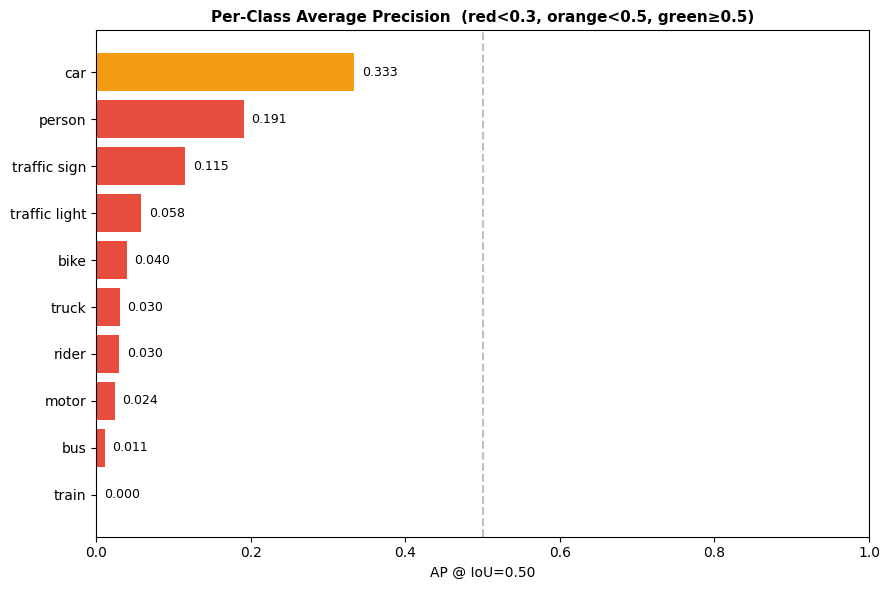

In [25]:
# Per-class AP chart
if 'map_per_class' in results:
    aps = {BDD_CLASSES[i]: results['map_per_class'][i].item()
           for i in range(min(len(BDD_CLASSES), len(results['map_per_class'])))}
    aps = dict(sorted(aps.items(), key=lambda x: x[1]))

    fig, ax = plt.subplots(figsize=(9, 6))
    bar_colors = ['#e74c3c' if v<0.3 else '#f39c12' if v<0.5 else '#27ae60'
                  for v in aps.values()]
    ax.barh(list(aps.keys()), list(aps.values()), color=bar_colors)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('AP @ IoU=0.50')
    ax.set_title('Per-Class Average Precision  (red<0.3, orange<0.5, green≥0.5)',
                 fontsize=11, fontweight='bold')
    for i, (cls, v) in enumerate(aps.items()):
        ax.text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('/content/outputs/eval/per_class_ap.png', dpi=150)
    plt.show()

## CELL 10 — FAILURE CLUSTERING
Find images where model fails → extract features → cluster → find patterns

In [26]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torchvision.models as tv_models
import torchvision.transforms as T

# Step 1: Find failure images (max IoU < 0.3)
print('Step 1: Scanning for failures...')
model.eval()
to_tensor    = T.ToTensor()
val_dataset2 = BDD100KDataset(VAL_IMAGES, VAL_LABELS, max_samples=300)
failures     = []

for sample in val_dataset2.samples:
    img      = Image.open(os.path.join(VAL_IMAGES, sample['image_name'])).convert('RGB')
    tensor   = to_tensor(img).unsqueeze(0).to(DEVICE)
    gt_boxes = torch.tensor(sample['boxes'], dtype=torch.float32)

    with torch.no_grad():
        out = model(tensor)[0]

    pred = out['boxes'][out['scores'] >= 0.3].cpu()
    max_iou = 0.0
    if len(pred) > 0 and len(gt_boxes) > 0:
        for pb in pred[:5]:
            for gb in gt_boxes[:5]:
                ix1=max(pb[0],gb[0]); iy1=max(pb[1],gb[1])
                ix2=min(pb[2],gb[2]); iy2=min(pb[3],gb[3])
                inter=max(0,ix2-ix1)*max(0,iy2-iy1)
                union=(pb[2]-pb[0])*(pb[3]-pb[1])+(gb[2]-gb[0])*(gb[3]-gb[1])-inter
                if union>0: max_iou=max(max_iou, inter/union)
    if max_iou < 0.3:
        failures.append((sample['image_name'], max_iou))

print(f'Found {len(failures)} failures out of {len(val_dataset2.samples)} scanned')

Step 1: Scanning for failures...
  [Dataset] 104 samples loaded
Found 39 failures out of 104 scanned


In [27]:
# Step 2: ResNet-50 embeddings
print('Step 2: Extracting visual features (ResNet-50)...')
backbone  = tv_models.resnet50(pretrained=True)
backbone  = torch.nn.Sequential(*list(backbone.children())[:-1]).eval().to(DEVICE)
transform = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

embeddings, iou_scores = [], []
with torch.no_grad():
    for name, iou in failures[:100]:
        img = Image.open(os.path.join(VAL_IMAGES, name)).convert('RGB')
        emb = backbone(transform(img).unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()
        embeddings.append(emb)
        iou_scores.append(iou)

embeddings = np.array(embeddings)
print(f'Embeddings: {embeddings.shape}  (each image = 2048-dim vector)')

Step 2: Extracting visual features (ResNet-50)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Embeddings: (39, 2048)  (each image = 2048-dim vector)


Step 3: Clustering...


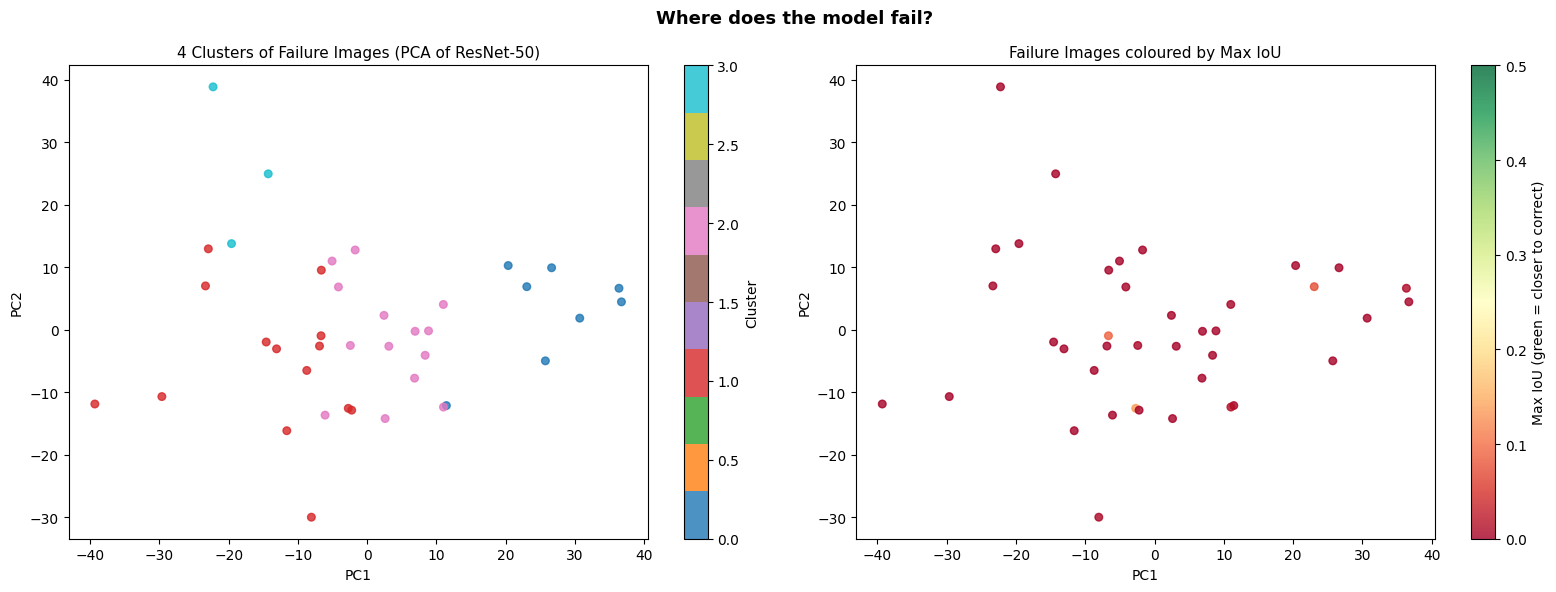


Cluster Summary:
  Cluster 0:   8 images | mean IoU = 0.011
  Cluster 1:  14 images | mean IoU = 0.017
  Cluster 2:  14 images | mean IoU = 0.002
  Cluster 3:   3 images | mean IoU = 0.000


In [28]:
# Step 3: KMeans + PCA
print('Step 3: Clustering...')
N   = 4
nrm = StandardScaler().fit_transform(embeddings)
clb = KMeans(n_clusters=N, random_state=42, n_init=10).fit_predict(nrm)
red = PCA(n_components=2, random_state=42).fit_transform(nrm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(red[:,0], red[:,1], c=clb, cmap='tab10', alpha=0.8, s=30)
plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set_title(f'{N} Clusters of Failure Images (PCA of ResNet-50)', fontsize=11)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

sc2 = axes[1].scatter(red[:,0], red[:,1],
                       c=iou_scores[:len(red)], cmap='RdYlGn',
                       alpha=0.8, s=30, vmin=0, vmax=0.5)
plt.colorbar(sc2, ax=axes[1], label='Max IoU (green = closer to correct)')
axes[1].set_title('Failure Images coloured by Max IoU', fontsize=11)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('Where does the model fail?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/failures/failure_clusters.png', dpi=150)
plt.show()

iou_arr = np.array(iou_scores[:len(clb)])
print('\nCluster Summary:')
for c in range(N):
    m = clb == c
    print(f'  Cluster {c}: {m.sum():3d} images | mean IoU = {iou_arr[m].mean():.3f}')

## CELL 11 — SAVE TO GOOGLE DRIVE

In [29]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

DRIVE_OUT = '/content/drive/MyDrive/bdd100k_cv_project'
shutil.copytree('/content/outputs', DRIVE_OUT, dirs_exist_ok=True)
print(f'✅ Saved to Google Drive: {DRIVE_OUT}')

print('\nFiles saved:')
for root, _, files in os.walk(DRIVE_OUT):
    for f in files:
        path = os.path.join(root, f)
        rel  = path.replace(DRIVE_OUT+'/', '')
        size = os.path.getsize(path)
        print(f'  {rel:<55} {size/1024:.0f} KB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved to Google Drive: /content/drive/MyDrive/bdd100k_cv_project

Files saved:
  qual/inference_samples.png                              2905 KB
  eval/per_class_ap.png                                   56 KB
  precomputed/figures/class_distribution.png              116 KB
  precomputed/figures/scene_metadata.png                  89 KB
  precomputed/figures/sample_annotated.png                707 KB
  precomputed/figures/train_val_comparison.png            50 KB
  precomputed/figures/bbox_analysis.png                   96 KB
  failures/failure_clusters.png                           109 KB
  model/model_final.pth                                   162025 KB
  model/loss_curve.png                                    45 KB
